In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_testing-set.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

# Filtrar o conjunto de treino para conter APENAS o tráfego normal
df_train_normal = df_train[df_train['label'] == 0]
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)

# Preparar o conjunto de teste completo
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['label'] # Rótulos verdadeiros para avaliação

# Definir e ajustar o pré-processador nos dados normais
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
print("Ajustando o pré-processador...")
preprocessor.fit(X_train_normal)

# Transformar os dados de treino e teste
print("Transformando os dados...")
X_train_normal_processed = preprocessor.transform(X_train_normal)
X_test_processed = preprocessor.transform(X_test)

print("Dados pré-processados e prontos.")

Ajustando o pré-processador...
Transformando os dados...
Dados pré-processados e prontos.


In [14]:
# Célula para testar diferentes percentis

# Assumindo que 'kmeans', 'X_test_processed' e 'y_test' já foram definidos
distances_test = kmeans.transform(X_test_processed).flatten()

percentiles_to_test = [90, 95, 97, 99]

for p in percentiles_to_test:
    threshold = np.percentile(distances_train, p)
    y_pred_kmeans = np.where(distances_test > threshold, 1, 0)
    
    print(f"\n--- Resultados para o Percentil {p}% (Threshold: {threshold:.2f}) ---")
    
    # Focando no f1-score que é uma boa métrica de balanço
    report = classification_report(y_test, y_pred_kmeans, target_names=['Normal (0)', 'Ataque (1)'], output_dict=True)
    f1_normal = report['Normal (0)']['f1-score']
    f1_ataque = report['Ataque (1)']['f1-score']
    
    print(f"F1-Score para 'Normal': {f1_normal:.2f}")
    print(f"F1-Score para 'Ataque': {f1_ataque:.2f}")
    print("-" * 50)

# Instanciar o KMeans. Vamos começar com k=1.
kmeans = KMeans(n_clusters=1, random_state=42, n_init='auto')

print("Treinando o modelo KMeans nos dados de treino normais...")
kmeans.fit(X_train_normal_processed)

# Calcular a distância de cada ponto de treino normal ao centroide
# O método .transform() do KMeans retorna a distância ao centroide de cada cluster
distances_train = kmeans.transform(X_train_normal_processed)

# Definir o limiar de anomalia como o percentil 95 das distâncias
# Isso significa que 5% dos dados de treino mais distantes seriam considerados "anomalias"
# threshold = np.percentile(distances_train, 95)
threshold = 8.60

print(f"\nTreinamento concluído.")
print(f"O limiar de anomalia (distância) foi definido como: {threshold:.4f}")


--- Resultados para o Percentil 90% (Threshold: 8.60) ---
F1-Score para 'Normal': 0.64
F1-Score para 'Ataque': 0.44
--------------------------------------------------

--- Resultados para o Percentil 95% (Threshold: 11.45) ---
F1-Score para 'Normal': 0.66
F1-Score para 'Ataque': 0.38
--------------------------------------------------

--- Resultados para o Percentil 97% (Threshold: 15.35) ---
F1-Score para 'Normal': 0.65
F1-Score para 'Ataque': 0.29
--------------------------------------------------

--- Resultados para o Percentil 99% (Threshold: 19.22) ---
F1-Score para 'Normal': 0.64
F1-Score para 'Ataque': 0.18
--------------------------------------------------
Treinando o modelo KMeans nos dados de treino normais...

Treinamento concluído.
O limiar de anomalia (distância) foi definido como: 8.6000


Calculando distâncias para os dados de teste...
Previsões concluídas.

--- Relatório de Classificação Binária (KMeans) ---
              precision    recall  f1-score   support

  Normal (0)       0.51      0.88      0.64     37000
  Ataque (1)       0.76      0.31      0.44     45332

    accuracy                           0.57     82332
   macro avg       0.63      0.59      0.54     82332
weighted avg       0.64      0.57      0.53     82332



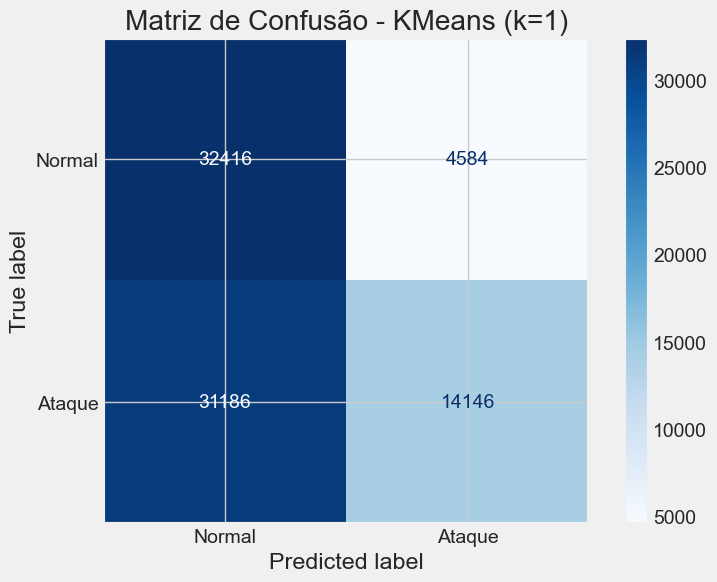

In [15]:
# Calcular a distância de cada ponto de teste ao centroide do cluster normal
print("Calculando distâncias para os dados de teste...")
distances_test = kmeans.transform(X_test_processed)
# Como k=1, distances_test é um array de (n_samples, 1), então usamos .flatten()
distances_test = distances_test.flatten()

# Classificar como anomalia (1) se a distância for maior que o limiar
y_pred_kmeans = np.where(distances_test > threshold, 1, 0)

print("Previsões concluídas.")

# Avaliar os resultados
print("\n--- Relatório de Classificação Binária (KMeans) ---")
print(classification_report(y_test, y_pred_kmeans, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test, y_pred_kmeans)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - KMeans (k=1)')
plt.show()